# Rental crisis in Portugal — H1: long-term rent vs wages

**Hypothesis H1:** the **long-term rental** price in Portugal (median €/m² per month of new lease contracts) has grown faster than wages since 2017.

| Data | Indicator | Coverage | Used for |
|---|---|---|---|
| Long-term rental price: median €/m² of new lease contracts, last 12 months (2021 methodology, NUTS 2013) | `0009817` | 2H 2017 – 2H 2023 | long-term rent 2017–2020 |
| Same indicator, NUTS 2024 geography | `0012598` | 2H 2020 – 2H 2024 | long-term rent 2020–2024 |
| Long-term rental price, 2026 methodology (same indicator as in the rest of the project) | `0014696` | 1Q 2020 – 2Q 2026 | long-term rent growth after 2024 (chain-linked) |
| Average gross monthly earnings per employee | `0011132` | 1Q 2014 – 2Q 2026 | wages |

All four come from INE (Statistics Portugal) via its **API**.

**Method:** all series are aligned to the same 12-month windows (ending June and December) and indexed to 2H 2017 = 100.

**Period:** 2H 2017 – 1H 2026. The last value is the 12 months to June 2026, the same latest period (2Q 2026) as in the rest of the project.

**Period labels:** `2H 2017` = second half of 2017 (July–December), `1Q 2026` = first quarter of 2026. They are written this way so they cannot be confused with the hypothesis names (H1, H2, …).

*Reminder: €/m² is the **monthly long-term rent per square metre** from signed contracts (INE), not a tourist price.*

**The story in 3 charts**

1. Growth since 2017: long-term rent vs wages (index).
2. The same data in euros: monthly rent for an 80 m² flat vs the average gross monthly salary.
3. Affordability: how much of an average salary that flat costs.

**Notebook structure**
1. Setup
2. Data collection (INE API)
3. Inspection
4. Cleaning: long-term rent
5. Chain-linking the 2026 methodology
6. Cleaning: wages
7. Main cleaning function
8. Analysis
9. Visualisation
10. Conclusion

## 1. Setup

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
import requests
from IPython.display import Markdown

pd.set_option("display.max_columns", None)

# Folders (this notebook lives in the repo root, next to the data and figures folders)
RAW_FOLDER = Path("data/raw")
CLEAN_FOLDER = Path("data/clean")
FIGURES_FOLDER = Path("figures")
for folder in [RAW_FOLDER, CLEAN_FOLDER, FIGURES_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

# INE API
INE_URL = "https://www.ine.pt/ine/json_indicador/pindica.jsp"

INDICATORS = {
    "rent_2013": "0009817",  # long-term rent: median €/m², last 12 months, semi-annual, 2021 methodology, NUTS 2013
    "rent_2024": "0012598",  # same indicator, NUTS 2024 geography
    "rent_2026": "0014696",  # long-term rent: median €/m², last 12 months, quarterly, 2026 methodology (as in the rest of the project)
    "wages": "0011132",      # average gross monthly earnings per employee, quarterly
}

# Analysis period
BASE_DATE = pd.Timestamp("2017-12-31")   # 2H 2017 = 100
CHAIN_DATE = pd.Timestamp("2024-12-31")  # last 2021-methodology value (2H 2024); 2026-methodology growth added after this
END_DATE = pd.Timestamp("2026-06-30")    # 12 months to June 2026 = latest period, the same as in the rest of the project

# Published INE figures used to validate the cleaned data
VALIDATION = {
    "rent_2h_2017": 4.39,         # national median long-term rent €/m², 12 months to Dec 2017
    "rent_2024": 7.97,            # national median long-term rent €/m², 2024
    "wage_total_4q_2025": 1877,   # average gross monthly earnings, total, quarter ended Dec 2025
    "wage_total_1q_2026": 1611,   # same, quarter ended Mar 2026
    "wage_base_1q_2026": 1335,    # base component, quarter ended Mar 2026
    "wage_total_2025": 1694,      # annual average 2025, total
}


def half_year_labels(index: pd.DatetimeIndex) -> list:
    """Readable period labels: 2017-12-31 -> '2H 2017', 2018-06-30 -> '1H 2018'."""
    return [f"{1 if date.month == 6 else 2}H {date.year}" for date in index]

## 2. Data collection (INE API)

- Each indicator is requested once with all periods (`Dim1="T"`) and cached as JSON in `data/raw/`. Later runs read the local file instead of calling the API again.
- INE's server can be slow: requests time out after 180 s and are retried up to 3 times, waiting longer after each failed attempt.
- The code of the 2026-methodology series (`0014696`) was found by searching Portugal's open data portal (dados.gov.pt), which harvests INE's indicators.

In [2]:
def fetch_ine(varcd: str, lang: str = "EN", use_cache: bool = True,
              retries: int = 3, timeout: int = 180) -> list:
    """Fetch all periods of one INE indicator as JSON and cache it locally."""
    cache = RAW_FOLDER / f"ine_{varcd}_all.json"
    if use_cache and cache.exists():
        return json.loads(cache.read_text(encoding="utf-8"))

    params = {"op": "2", "varcd": varcd, "lang": lang, "Dim1": "T"}
    for attempt in range(1, retries + 1):
        try:
            response = requests.get(INE_URL, params=params, timeout=timeout)
            response.raise_for_status()
            payload = response.json()
            break
        except (requests.Timeout, requests.ConnectionError) as err:
            if attempt == retries:
                raise
            wait = 15 * attempt
            print(f"{varcd}: attempt {attempt} failed ({type(err).__name__}), retrying in {wait}s")
            time.sleep(wait)

    cache.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    return payload


def describe_payload(payload: list) -> None:
    """Print indicator code, name, last update and period range."""
    meta = payload[0]
    periods = list(meta["Dados"].keys())
    print("Code:    ", meta["IndicadorCod"])
    print("Name:    ", meta["IndicadorDsg"])
    print("Updated: ", meta["DataUltimoAtualizacao"])
    print("Periods: ", len(periods), "|", periods[0], "→", periods[-1])
    print("-" * 90)

In [3]:
payloads = {name: fetch_ine(code) for name, code in INDICATORS.items()}

for payload in payloads.values():
    describe_payload(payload)

Code:     0009817
Name:     Median house rental value of new lease agreements of dwellings in the last 12 months (2021 Methodology - €/ m²) by Geographic location (NUTS - 2013); Semi-annual - Statistics Portugal, House rental statistics at local level
Updated:  2024-03-28
Periods:  13 | 2nd Semi-annual 2017 → 2nd Semi-annual 2023
------------------------------------------------------------------------------------------
Code:     0012598
Name:     Median house rental value of new lease agreements of dwellings in the last 12 months (2021 Methodology - €/ m²) by Geographic localization (NUTS - 2024); Semi-annual - Statistics Portugal, House rental statistics at local level
Updated:  2025-06-27
Periods:  9 | 2nd Semi-annual 2020 → 2nd Semi-annual 2024
------------------------------------------------------------------------------------------
Code:     0014696
Name:     Median house rental value of new lease agreements of dwellings in the last 12 months (2026 Methodology - €/ m²) by Geograph

## 3. Inspection

- **Long-term rent:** one row per geographic unit per period (country, regions, municipalities). Values are medians of the **last 12 months**. Labels are semi-annual in the 2021 methodology ("2nd Semi-annual 2017") and quarterly in the 2026 methodology ("4th Quarter 2025").
- **Wages:** labels are monthly, but each value refers to the **quarter ending in that month** ("March 2026" = 1Q 2026). There are 20 rows per period: earnings component (`dim_3`) × activity type (`dim_4`).
- `valor` is the numeric value stored as text; `ind_string` is the same value formatted with a decimal comma; `sinal_conv` marks unavailable or confidential values.

In [4]:
def flatten_ine(payload: list) -> pd.DataFrame:
    """Turn INE's nested {period: [records]} structure into a flat DataFrame."""
    rows = [
        {"period": period, **record}
        for period, records in payload[0]["Dados"].items()
        for record in records
    ]
    return pd.DataFrame(rows)


raw = {name: flatten_ine(payload) for name, payload in payloads.items()}

for name, df in raw.items():
    n_pt = (df["geocod"] == "PT").sum()
    print(f"{name:10} shape: {str(df.shape):12} periods: {df['period'].nunique():4}   rows for Portugal: {n_pt}")

rent_2013  shape: (8255, 7)    periods:   13   rows for Portugal: 13
rent_2024  shape: (5742, 7)    periods:    9   rows for Portugal: 9
rent_2026  shape: (16588, 7)   periods:   26   rows for Portugal: 26
wages      shape: (2960, 11)   periods:  148   rows for Portugal: 2960


In [5]:
# Wage dimensions: we need the Total component (dim_3 = T) and all activities (dim_4 = T)
raw["wages"][["dim_3", "dim_3_t", "dim_4", "dim_4_t"]].drop_duplicates().reset_index(drop=True)

,dim_3,dim_3_t,dim_4,dim_4_t
0,1,Regular,1,Tradable
1,11,Base,1,Tradable
2,12,Other regular components,1,Tradable
3,2,Non-regular,1,Tradable
4,T,Total,1,Tradable
5,1,Regular,2,Non-tradable market
6,11,Base,2,Non-tradable market
7,12,Other regular components,2,Non-tradable market
8,2,Non-regular,2,Non-tradable market
9,T,Total,2,Non-tradable market


In [6]:
# Rent, Portugal: first rows of each series
for name in ["rent_2013", "rent_2024", "rent_2026"]:
    df = raw[name]
    display(df.loc[df["geocod"] == "PT", ["period", "geocod", "geodsg", "valor", "sinal_conv"]].head(3))

,period,geocod,geodsg,valor,sinal_conv
255,2nd Semi-annual 2017,PT,Portugal,4.39,NaN
885,1st Semi-annual 2018,PT,Portugal,4.58,NaN
1519,2nd Semi-annual 2018,PT,Portugal,4.8,NaN


,period,geocod,geodsg,valor,sinal_conv
233,2nd Semi-annual 2020,PT,Portugal,5.61,NaN
878,1st Semi-annual 2021,PT,Portugal,5.82,NaN
1520,2nd Semi-annual 2021,PT,Portugal,6.04,NaN


,period,geocod,geodsg,valor,sinal_conv
173,1st Quarter 2020,PT,Portugal,5.56,NaN
811,2nd Quarter 2020,PT,Portugal,5.62,NaN
1449,3rd Quarter 2020,PT,Portugal,5.71,NaN


## 4. Cleaning: long-term rent

1. Filter to Portugal (`geocod == "PT"`) and keep only the needed columns
2. Parse period labels into end-of-period dates (semesters and quarters)
3. Convert `valor` to numeric
4. Keep only periods ending in June and December, so all three series use the same 12-month windows
5. Check for missing values and duplicate dates
6. Combine the two 2021-methodology series (NUTS 2013 and NUTS 2024): at national level they should be identical, so the newer one extends the older one to 2H 2024

In [7]:
PERIOD_END = {
    "Semi-annual": {"1st": "06-30", "2nd": "12-31"},
    "Quarter": {"1st": "03-31", "2nd": "06-30", "3rd": "09-30", "4th": "12-31"},
}


def parse_period(label: str) -> pd.Timestamp:
    """'2nd Semi-annual 2017' -> 2017-12-31; '3rd Quarter 2020' -> 2020-09-30."""
    number, kind, year = label.split()
    return pd.Timestamp(f"{year}-{PERIOD_END[kind][number]}")


def clean_rent(df: pd.DataFrame, geocod: str = "PT") -> pd.Series:
    """Long-term rent (median €/m² of new lease contracts, last 12 months) for one area, at June and December period ends."""
    rent = df.loc[df["geocod"] == geocod, ["period", "valor"]].copy()
    if rent.empty:
        raise ValueError(f"No rows found for geocod '{geocod}'")

    rent["date"] = rent["period"].apply(parse_period)
    rent["valor"] = pd.to_numeric(rent["valor"], errors="coerce")
    rent = rent[rent["date"].dt.month.isin([6, 12])]

    if rent["date"].duplicated().any():
        raise ValueError("Duplicate dates found")
    return rent.set_index("date")["valor"].sort_index().rename("long_term_rent")


def check(label: str, actual: float, expected: float, tolerance: float = 0.0) -> None:
    """Compare a cleaned value with a published INE figure."""
    status = "OK   " if abs(actual - expected) <= tolerance else "CHECK"
    print(f"[{status}] {label}: {actual:,.2f} (published: {expected:,.2f})")

In [8]:
rent_2013 = clean_rent(raw["rent_2013"])
rent_2024 = clean_rent(raw["rent_2024"])
rent_2026 = clean_rent(raw["rent_2026"])

for name, series in [("rent_2013", rent_2013), ("rent_2024", rent_2024), ("rent_2026", rent_2026)]:
    print(f"{name}: {len(series):2} values | {series.index.min().date()} → {series.index.max().date()}"
          f" | missing: {series.isna().sum()}")

print()
check("Long-term rent 2H 2017", rent_2013.loc[BASE_DATE], VALIDATION["rent_2h_2017"], tolerance=0.01)
check("Long-term rent 2H 2024", rent_2024.loc[CHAIN_DATE], VALIDATION["rent_2024"], tolerance=0.01)

rent_2013: 13 values | 2017-12-31 → 2023-12-31 | missing: 0
rent_2024:  9 values | 2020-12-31 → 2024-12-31 | missing: 0
rent_2026: 13 values | 2020-06-30 → 2026-06-30 | missing: 0

[OK   ] Long-term rent 2H 2017: 4.39 (published: 4.39)
[OK   ] Long-term rent 2H 2024: 7.97 (published: 7.97)


In [9]:
# The two 2021-methodology series overlap from 2H 2020 to 2H 2023: national values should match
overlap = pd.concat({"nuts_2013": rent_2013, "nuts_2024": rent_2024}, axis=1).dropna()
overlap["difference"] = (overlap["nuts_2024"] - overlap["nuts_2013"]).round(2)
display(overlap)

# Newer series takes priority where both exist; the older one fills 2H 2017 – 1H 2020
rent_2021 = rent_2024.combine_first(rent_2013)
print(f"Combined 2021 methodology: {len(rent_2021)} values | "
      f"{rent_2021.index.min().date()} → {rent_2021.index.max().date()}")

,nuts_2013,nuts_2024,difference
date,,,
2020-12-31,5.61,5.61,0.0
2021-06-30,5.82,5.82,0.0
2021-12-31,6.04,6.04,0.0
2022-06-30,6.25,6.25,0.0
2022-12-31,6.52,6.52,0.0
2023-06-30,6.86,6.86,0.0
2023-12-31,7.21,7.21,0.0


Combined 2021 methodology: 15 values | 2017-12-31 → 2024-12-31


## 5. Chain-linking the 2026 methodology

In 2026 INE revised its long-term rent statistics. The new series gives different **levels** from the old one (end of 2020: 5.79 vs 5.61 €/m²), so the two cannot simply be joined end to end.

1. **Check:** index both methodologies to 2H 2020 = 100 and compare their growth over the overlap (2H 2020 – 2H 2024).
2. **Chain:** keep the 2021-methodology values up to 2H 2024 and extend them with the **growth** of the 2026 methodology:

   `rent(t) = rent_2021(2H 2024) × rent_2026(t) / rent_2026(2H 2024)`

This way 2017–2024 stays entirely in one methodology, and the new methodology only contributes the change after 2H 2024.

In [10]:
comparison = pd.concat({"2021 methodology": rent_2021, "2026 methodology": rent_2026}, axis=1)
comparison = comparison.loc["2020-12-31":CHAIN_DATE]
comparison_idx = comparison.div(comparison.iloc[0]).mul(100).round(1)
comparison_idx["difference_pp"] = (comparison_idx["2026 methodology"]
                                   - comparison_idx["2021 methodology"]).round(1)
display(comparison_idx)

growth_2021_method = comparison_idx["2021 methodology"].iloc[-1] - 100
growth_2026_method = comparison_idx["2026 methodology"].iloc[-1] - 100
print(f"Long-term rent growth 2H 2020 → 2H 2024:  2021 methodology +{growth_2021_method:.1f}%  |  "
      f"2026 methodology +{growth_2026_method:.1f}%")

,2021 methodology,2026 methodology,difference_pp
date,,,
2020-12-31,100.0,100.0,0.0
2021-06-30,103.7,103.5,-0.2
2021-12-31,107.7,109.0,1.3
2022-06-30,111.4,114.0,2.6
2022-12-31,116.2,118.8,2.6
2023-06-30,122.3,124.0,1.7
2023-12-31,128.5,131.6,3.1
2024-06-30,135.5,139.2,3.7
2024-12-31,142.1,146.3,4.2


Long-term rent growth 2H 2020 → 2H 2024:  2021 methodology +42.1%  |  2026 methodology +46.3%


In [11]:
def chain_series(old: pd.Series, new: pd.Series, chain_date: pd.Timestamp) -> pd.Series:
    """Extend `old` beyond chain_date using the growth of `new` (chain-linking)."""
    factor = old.loc[chain_date] / new.loc[chain_date]
    extension = new.loc[new.index > chain_date] * factor
    return pd.concat([old, extension]).round(2)


rent_chained = chain_series(rent_2021, rent_2026, CHAIN_DATE)
rent_chained.loc["2024-06-30":]

date
2024-06-30    7.60
2024-12-31    7.97
2025-06-30    8.39
2025-12-31    8.74
2026-06-30    9.18
Name: long_term_rent, dtype: float64

## 6. Cleaning: wages

1. Keep all activities (`dim_4 == "T"`) and two components: **Total** (`T`, includes holiday and Christmas bonuses) and **Base** (`11`, used as a sensitivity check)
2. Parse month labels into dates and convert values to numeric
3. Keep only March, June, September and December: each is a separate, non-overlapping quarter
4. Reshape to one row per quarter with one column per component
5. Rolling mean over 4 quarters → 12-month average, kept at June and December to match the rent windows

In [12]:
WAGE_COMPONENTS = {"T": "wage_total", "11": "wage_base"}

MONTHS = {"January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
          "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}


def parse_month(label: str) -> pd.Timestamp:
    """'March 2026' -> 2026-03-31 (last day of the month)."""
    month, year = label.split()
    return pd.Timestamp(year=int(year), month=MONTHS[month], day=1) + pd.offsets.MonthEnd(0)


def clean_wages(df: pd.DataFrame) -> pd.DataFrame:
    """Quarterly earnings (total and base), all activities, indexed by quarter-end date."""
    wages = df[["period", "dim_3", "dim_4", "valor"]].astype({"dim_3": str, "dim_4": str})
    wages = wages[(wages["dim_4"] == "T") & (wages["dim_3"].isin(WAGE_COMPONENTS))].copy()

    wages["date"] = wages["period"].apply(parse_month)
    wages["valor"] = pd.to_numeric(wages["valor"], errors="coerce")
    wages = wages[wages["date"].dt.month.isin([3, 6, 9, 12])]

    wages = wages.pivot(index="date", columns="dim_3", values="valor").rename(columns=WAGE_COMPONENTS)
    wages.columns.name = None
    return wages[list(WAGE_COMPONENTS.values())].sort_index()


def wages_to_12m(wages_q: pd.DataFrame) -> pd.DataFrame:
    """12-month average (mean of 4 quarters), kept at June and December."""
    wages_12m = wages_q.rolling(window=4).mean()
    return wages_12m[wages_12m.index.month.isin([6, 12])].dropna()

In [13]:
wages_q = clean_wages(raw["wages"])
wages_12m = wages_to_12m(wages_q)

print(f"Quarterly: {wages_q.shape[0]} quarters | {wages_q.index.min().date()} → {wages_q.index.max().date()}"
      f" | missing: {wages_q.isna().sum().sum()}")
print(f"Largest gap between quarters: {wages_q.index.to_series().diff().dt.days.max():.0f} days")
print()
check("Wages total, 4Q 2025", wages_q.loc["2025-12-31", "wage_total"], VALIDATION["wage_total_4q_2025"], tolerance=5)
check("Wages total, 1Q 2026", wages_q.loc["2026-03-31", "wage_total"], VALIDATION["wage_total_1q_2026"], tolerance=5)
check("Wages base,  1Q 2026", wages_q.loc["2026-03-31", "wage_base"], VALIDATION["wage_base_1q_2026"], tolerance=5)
check("Wages total, 12 months to Dec 2025", wages_12m.loc["2025-12-31", "wage_total"],
      VALIDATION["wage_total_2025"], tolerance=10)

Quarterly: 50 quarters | 2014-03-31 → 2026-06-30 | missing: 0
Largest gap between quarters: 92 days

[CHECK] Wages total, 4Q 2025: 1,883.00 (published: 1,877.00)
[OK   ] Wages total, 1Q 2026: 1,616.00 (published: 1,611.00)
[OK   ] Wages base,  1Q 2026: 1,333.00 (published: 1,335.00)
[OK   ] Wages total, 12 months to Dec 2025: 1,695.00 (published: 1,694.00)


`OK` = matches the figure INE published at the time (within a small tolerance). `CHECK` = look closer.

**Result:** 4Q 2025 (1,883 € vs 1,877 € published in Feb 2026) and 1Q 2026 (1,616 € vs 1,611 €) are slightly higher than first published. Both differences are small (≈0.3%) and point in the same direction, consistent with INE revising the data in later releases (last update: August 2026). The cleaning is correct; the API simply returns the latest revised figures.

The 12-month average is a simple mean of four quarters, while INE's annual figure weights each quarter by its number of jobs, so a difference of a few euros is expected there.

## 7. Main cleaning function

`clean_all()` runs the whole pipeline in order, from the raw API tables to one aligned table: long-term rent (combined and chain-linked) and 12-month wages per half-year, 2H 2017 – 1H 2026.

In [14]:
def clean_all(raw: dict) -> pd.DataFrame:
    """Raw INE tables -> aligned half-yearly table of long-term rent and wages for the analysis period."""
    rent_2021 = clean_rent(raw["rent_2024"]).combine_first(clean_rent(raw["rent_2013"]))
    rent = chain_series(rent_2021, clean_rent(raw["rent_2026"]), CHAIN_DATE)
    wages = wages_to_12m(clean_wages(raw["wages"]))

    h1 = pd.concat([rent, wages], axis=1, join="inner").loc[BASE_DATE:END_DATE]
    h1["rent_source"] = ["2026 methodology (chain-linked)" if date > CHAIN_DATE else "2021 methodology"
                         for date in h1.index]
    return h1


h1 = clean_all(raw)

print(f"{len(h1)} half-years | {h1.index.min().date()} → {h1.index.max().date()} | "
      f"missing: {h1.isna().sum().sum()}")
h1

18 half-years | 2017-12-31 → 2026-06-30 | missing: 0


,long_term_rent,wage_total,wage_base,rent_source
date,,,,
2017-12-31,4.39,1215.00,937.75,2021 methodology
2018-06-30,4.58,1218.25,943.25,2021 methodology
2018-12-31,4.80,1240.25,952.75,2021 methodology
2019-06-30,5.00,1257.00,964.00,2021 methodology
2019-12-31,5.32,1275.75,976.25,2021 methodology
2020-06-30,5.47,1290.50,990.25,2021 methodology
2020-12-31,5.61,1315.50,1008.75,2021 methodology
2021-06-30,5.82,1343.25,1028.25,2021 methodology
2021-12-31,6.04,1360.25,1039.00,2021 methodology


## 8. Analysis

All three series are indexed to 2H 2017 = 100, so growth can be compared directly even though the units differ (€/m² vs €/month).

In [15]:
VALUE_COLUMNS = ["long_term_rent", "wage_total", "wage_base"]


def add_index(df: pd.DataFrame, base_date: pd.Timestamp) -> pd.DataFrame:
    """Index every column to base_date = 100."""
    return df.div(df.loc[base_date]).mul(100).round(1).add_suffix("_idx")


h1_idx = add_index(h1[VALUE_COLUMNS], BASE_DATE)
h1_full = h1.join(h1_idx)

growth = h1_idx.iloc[-1] - 100
gap = growth["long_term_rent_idx"] - growth["wage_total_idx"]

start_label, end_label = half_year_labels(h1_idx.index[[0, -1]])
print(f"Growth {start_label} → {end_label} (12-month windows)")
print(f"  Long-term rent (€/m²):    +{growth['long_term_rent_idx']:.1f}%")
print(f"  Wages, total:             +{growth['wage_total_idx']:.1f}%")
print(f"  Wages, base:              +{growth['wage_base_idx']:.1f}%")
print(f"  Gap, rent vs total wages: {gap:.1f} percentage points")
print(f"  Long-term rent increase = {growth['long_term_rent_idx'] / growth['wage_total_idx']:.1f}x the total wage increase")

h1_full

Growth 2H 2017 → 1H 2026 (12-month windows)
  Long-term rent (€/m²):    +109.1%
  Wages, total:             +43.0%
  Wages, base:              +39.5%
  Gap, rent vs total wages: 66.1 percentage points
  Long-term rent increase = 2.5x the total wage increase


,long_term_rent,wage_total,wage_base,rent_source,long_term_rent_idx,wage_total_idx,wage_base_idx
date,,,,,,,
2017-12-31,4.39,1215.00,937.75,2021 methodology,100.0,100.0,100.0
2018-06-30,4.58,1218.25,943.25,2021 methodology,104.3,100.3,100.6
2018-12-31,4.80,1240.25,952.75,2021 methodology,109.3,102.1,101.6
2019-06-30,5.00,1257.00,964.00,2021 methodology,113.9,103.5,102.8
2019-12-31,5.32,1275.75,976.25,2021 methodology,121.2,105.0,104.1
2020-06-30,5.47,1290.50,990.25,2021 methodology,124.6,106.2,105.6
2020-12-31,5.61,1315.50,1008.75,2021 methodology,127.8,108.3,107.6
2021-06-30,5.82,1343.25,1028.25,2021 methodology,132.6,110.6,109.7
2021-12-31,6.04,1360.25,1039.00,2021 methodology,137.6,112.0,110.8


**In euros, not indexed.** The index shows *growth*; the next step shows *amounts*. To compare rent (€/m²) with wages (€/month) in the same unit, we use the monthly rent of an **80 m² flat**, the same example as in the other project notebooks.

* `rent_80m2` – monthly long-term rent for an 80 m² flat (€)
* `rent_share_of_wage_pct` – that rent as a share of average gross monthly earnings (%)

*Illustrative: a median rent of new lease contracts compared with average gross earnings before tax.*

In [16]:
FLAT_SIZE_M2 = 80   # example flat, the same as in the other project notebooks

affordability = pd.DataFrame({
    "rent_80m2": h1["long_term_rent"] * FLAT_SIZE_M2,
    "wage_total": h1["wage_total"],
})
affordability["rent_share_of_wage_pct"] = affordability["rent_80m2"] / affordability["wage_total"] * 100

h1_full = h1_full.join(affordability[["rent_80m2", "rent_share_of_wage_pct"]])
h1_full.to_csv(CLEAN_FOLDER / "h1_clean.csv")

first, last = affordability.iloc[0], affordability.iloc[-1]
print(f"Monthly rent, {FLAT_SIZE_M2} m² flat:    {first['rent_80m2']:,.0f} € → {last['rent_80m2']:,.0f} €")
print(f"Average gross monthly earnings: {first['wage_total']:,.0f} € → {last['wage_total']:,.0f} €")
print(f"Rent as a share of earnings:    {first['rent_share_of_wage_pct']:.1f}% → {last['rent_share_of_wage_pct']:.1f}%")
affordability.round(1)

Monthly rent, 80 m² flat:    351 € → 734 €
Average gross monthly earnings: 1,215 € → 1,738 €
Rent as a share of earnings:    28.9% → 42.3%


,rent_80m2,wage_total,rent_share_of_wage_pct
date,,,
2017-12-31,351.2,1215.0,28.9
2018-06-30,366.4,1218.2,30.1
2018-12-31,384.0,1240.2,31.0
2019-06-30,400.0,1257.0,31.8
2019-12-31,425.6,1275.8,33.4
2020-06-30,437.6,1290.5,33.9
2020-12-31,448.8,1315.5,34.1
2021-06-30,465.6,1343.2,34.7
2021-12-31,483.2,1360.2,35.5


## 9. Visualisation

**Chart style** – the same clean look as in the other project notebooks: white background, one blue accent, grey text for secondary information, no chart borders, values written on the chart instead of a legend.

In [17]:
# Colours: the same palette as in the other project notebooks (tested for colour-blind readers)
ACCENT = "#1c5cab"        # dark blue  = main data (long-term rent)
LIGHT_BLUE = "#86b6ef"    # light blue = comparison (wages)
INK = "#0b0b0b"           # main text
GREY_TEXT = "#52514e"     # subtitles
MUTED = "#898781"         # axis text and source notes
GRID = "#e1e0d9"          # thin gridlines

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": GRID, "axes.labelcolor": GREY_TEXT,
    "xtick.color": GREY_TEXT, "ytick.color": MUTED, "xtick.labelsize": 11, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.fontsize": 10, "legend.labelcolor": GREY_TEXT,
})


def add_titles(fig, title, subtitle):
    """Bold headline that states the finding + grey subtitle that says what is measured."""
    fig.suptitle(title, x=0.02, y=0.98, ha="left", fontsize=15, fontweight="bold", color=INK)
    fig.text(0.02, 0.905, subtitle, ha="left", fontsize=11, color=GREY_TEXT)


def add_source(fig, text):
    """Small grey note at the bottom left (source, footnotes)."""
    fig.text(0.02, 0.015, text, ha="left", fontsize=8.5, color=MUTED)


def clean_bar_axes(ax):
    """Bar charts: values are written on the bars, so we hide the y axis and keep only the baseline."""
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="x", length=0, pad=8)
    ax.margins(y=0.15)


def save_chart(fig, file_name):
    """Leave room for titles and source, save in high resolution for slides, then show."""
    fig.tight_layout(rect=(0, 0.05, 1, 0.87))
    fig.savefig(FIGURES_FOLDER / file_name, dpi=200)
    plt.show()

### Chart 1 – Growth since 2017: long-term rent vs wages (index)

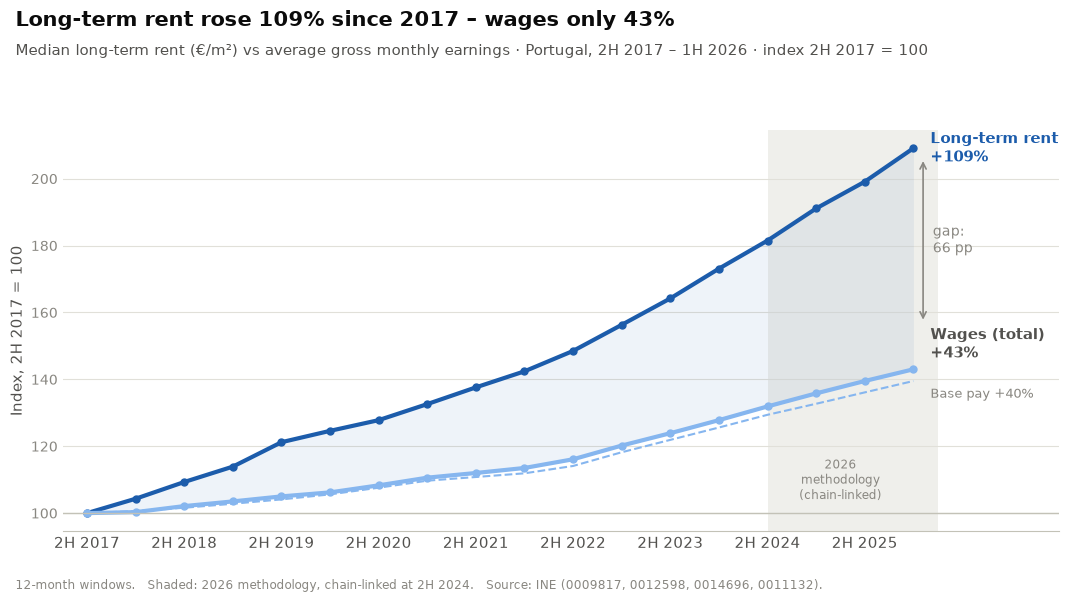

In [18]:
# Chart 1 – growth since 2017 (index)
growth_rent = h1_idx["long_term_rent_idx"].iloc[-1] - 100
growth_wage = h1_idx["wage_total_idx"].iloc[-1] - 100
growth_base = h1_idx["wage_base_idx"].iloc[-1] - 100
rent_end, wage_end, base_end = h1_idx[["long_term_rent_idx", "wage_total_idx", "wage_base_idx"]].iloc[-1]

x = list(range(len(h1_idx)))
chain_pos = h1_idx.index.get_loc(CHAIN_DATE)
labels = half_year_labels(h1_idx.index)

fig, ax = plt.subplots(figsize=(11, 6))

# Chain-linked period (2026 methodology) in the background
ax.axvspan(chain_pos, x[-1] + 0.5, color=GRID, alpha=0.5, linewidth=0)
ax.text((chain_pos + x[-1]) / 2, 103, "2026\nmethodology\n(chain-linked)", ha="center", va="bottom",
        fontsize=8.5, color=MUTED)

# Gap between long-term rent and wages
ax.fill_between(x, h1_idx["wage_total_idx"], h1_idx["long_term_rent_idx"], color=ACCENT, alpha=0.07, linewidth=0)

ax.plot(x, h1_idx["long_term_rent_idx"], color=ACCENT, linewidth=3, marker="o", markersize=5)
ax.plot(x, h1_idx["wage_total_idx"], color=LIGHT_BLUE, linewidth=3, marker="o", markersize=5)
ax.plot(x, h1_idx["wage_base_idx"], color=LIGHT_BLUE, linewidth=1.5, linestyle="--")
ax.axhline(100, color="#c3c2b7", linewidth=1)

# Values written at the line ends instead of a legend
end = x[-1] + 0.35
ax.text(end, rent_end, f"Long-term rent\n+{growth_rent:.0f}%", color=ACCENT, fontweight="bold", va="center")
ax.text(end, wage_end + 2, f"Wages (total)\n+{growth_wage:.0f}%", color=GREY_TEXT, fontweight="bold", va="bottom")
ax.text(end, base_end - 2, f"Base pay +{growth_base:.0f}%", color=MUTED, fontsize=9.5, va="top")

# Gap marker at the last period
ax.annotate("", xy=(x[-1] + 0.2, rent_end - 3), xytext=(x[-1] + 0.2, wage_end + 14),
            arrowprops=dict(arrowstyle="<->", color=MUTED, linewidth=1.2))
ax.text(x[-1] + 0.4, (rent_end + wage_end + 11) / 2, f"gap:\n{growth_rent - growth_wage:.0f} pp",
        color=MUTED, va="center", fontsize=10)

ax.set_xticks(x[::2], labels[::2])
ax.set_xlim(-0.5, x[-1] + 3)
ax.set_ylabel("Index, 2H 2017 = 100")
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(length=0)

add_titles(fig, f"Long-term rent rose {growth_rent:.0f}% since 2017 – wages only {growth_wage:.0f}%",
           "Median long-term rent (€/m²) vs average gross monthly earnings · Portugal, "
           f"{labels[0]} – {labels[-1]} · index {labels[0]} = 100")
add_source(fig, "12-month windows.   Shaded: 2026 methodology, chain-linked at 2H 2024.   "
                "Source: INE (0009817, 0012598, 0014696, 0011132).")
save_chart(fig, "h1_1_long_term_rent_vs_wages.png")

### Chart 2 – The same data in euros (not indexed)

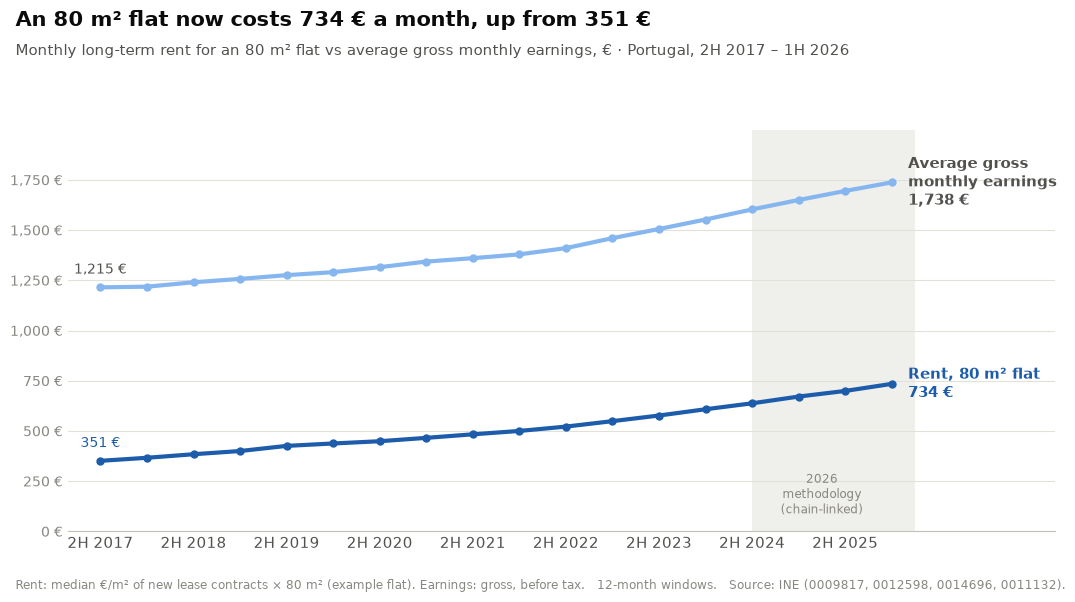

In [19]:
# Chart 2 – monthly rent for an 80 m² flat vs average gross monthly earnings, in €
rent_80 = affordability["rent_80m2"]
wage = affordability["wage_total"]
x = list(range(len(affordability)))
chain_pos = affordability.index.get_loc(CHAIN_DATE)
labels = half_year_labels(affordability.index)

fig, ax = plt.subplots(figsize=(11, 6))

# Chain-linked period (2026 methodology) in the background
ax.axvspan(chain_pos, x[-1] + 0.5, color=GRID, alpha=0.5, linewidth=0)
ax.text((chain_pos + x[-1]) / 2, wage.max() * 0.04, "2026\nmethodology\n(chain-linked)", ha="center",
        va="bottom", fontsize=8.5, color=MUTED)

ax.plot(x, wage, color=LIGHT_BLUE, linewidth=3, marker="o", markersize=5)
ax.plot(x, rent_80, color=ACCENT, linewidth=3, marker="o", markersize=5)

# Start and end values written on the chart
for series, color, name in [(wage, GREY_TEXT, "Average gross\nmonthly earnings"),
                            (rent_80, ACCENT, f"Rent, {FLAT_SIZE_M2} m² flat")]:
    ax.text(x[0], series.iloc[0] + wage.max() * 0.03, f"{series.iloc[0]:,.0f} €", ha="center", va="bottom",
            color=color, fontsize=10)
    ax.text(x[-1] + 0.35, series.iloc[-1], f"{name}\n{series.iloc[-1]:,.0f} €", ha="left", va="center",
            color=color, fontweight="bold")

ax.set_ylim(0, wage.max() * 1.15)                       # € amounts: the axis starts at zero
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f} €"))
ax.set_xticks(x[::2], labels[::2])
ax.set_xlim(-0.7, x[-1] + 3.5)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(length=0)

add_titles(fig, f"An {FLAT_SIZE_M2} m² flat now costs {rent_80.iloc[-1]:,.0f} € a month, "
                f"up from {rent_80.iloc[0]:,.0f} €",
           f"Monthly long-term rent for an {FLAT_SIZE_M2} m² flat vs average gross monthly earnings, € · Portugal, "
           f"{labels[0]} – {labels[-1]}")
add_source(fig, f"Rent: median €/m² of new lease contracts × {FLAT_SIZE_M2} m² (example flat). Earnings: gross, "
                "before tax.   12-month windows.   Source: INE (0009817, 0012598, 0014696, 0011132).")
save_chart(fig, "h1_2_rent_and_wages_in_euros.png")

### Chart 3 – Affordability: rent as a share of the average salary

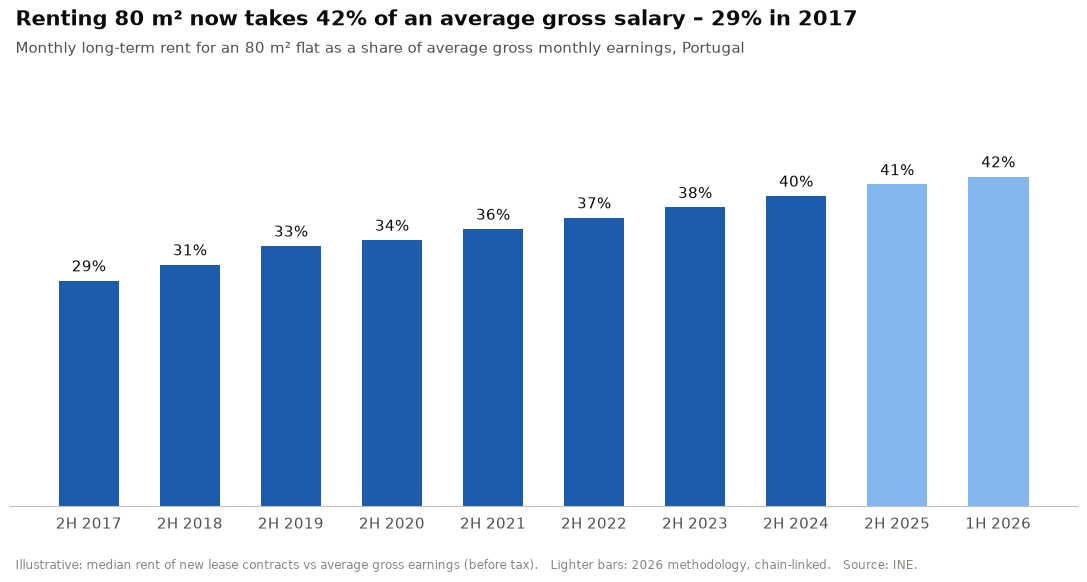

In [20]:
# Chart 3 – monthly rent for an 80 m² flat as a share of average gross monthly earnings
share = affordability["rent_share_of_wage_pct"]
dates = [date for date in share.index if date.month == 12]       # one bar per year (12 months to December) ...
if share.index[-1] not in dates:
    dates.append(share.index[-1])                                 # ... plus the latest 12 months
shown = share.loc[dates]
colors = [LIGHT_BLUE if date > CHAIN_DATE else ACCENT for date in shown.index]

fig, ax = plt.subplots(figsize=(11, 5.8))
bars = ax.bar(half_year_labels(shown.index), shown.values, color=colors, width=0.6)
ax.bar_label(bars, labels=[f"{value:.0f}%" for value in shown.values], padding=4, fontsize=11, color=INK)
clean_bar_axes(ax)

add_titles(fig, f"Renting {FLAT_SIZE_M2} m² now takes {shown.iloc[-1]:.0f}% of an average gross salary "
                f"– {shown.iloc[0]:.0f}% in 2017",
           f"Monthly long-term rent for an {FLAT_SIZE_M2} m² flat as a share of average gross monthly earnings, "
           "Portugal")
add_source(fig, "Illustrative: median rent of new lease contracts vs average gross earnings (before tax).   "
                "Lighter bars: 2026 methodology, chain-linked.   Source: INE.")
save_chart(fig, "h1_3_rent_share_of_salary.png")

## 10. Conclusion

The numbers in the conclusion are filled in automatically from the results above, so they always match the data.

In [21]:
start_label, end_label = half_year_labels(h1.index[[0, -1]])
chain_label = half_year_labels(pd.DatetimeIndex([CHAIN_DATE]))[0]

rent_growth = growth["long_term_rent_idx"]
wage_growth = growth["wage_total_idx"]
base_growth = growth["wage_base_idx"]
rent_2021_only = h1_idx.loc[CHAIN_DATE, "long_term_rent_idx"] - 100      # up to 2H 2024, old methodology only
wage_2021_only = h1_idx.loc[CHAIN_DATE, "wage_total_idx"] - 100

rent_start, rent_end = h1["long_term_rent"].iloc[[0, -1]]
wage_start, wage_end = affordability["wage_total"].iloc[[0, -1]]
rent_80_start, rent_80_end = affordability["rent_80m2"].iloc[[0, -1]]
share_start, share_end = affordability["rent_share_of_wage_pct"].iloc[[0, -1]]

verdict = "supported" if gap > 0 else "not supported"
share_note = ("Rent now takes a clearly bigger part of the salary than before." if share_end > share_start
              else "Rent does not take a bigger part of the salary than before.")
robust_note = ("the result does not depend on chain-linking." if rent_2021_only > wage_2021_only
               else "without the chain-linked years the result changes.")
methodology_note = ("The new methodology shows slightly faster growth, so using the old one up to "
                    f"{chain_label} is the conservative choice."
                    if growth_2026_method > growth_2021_method else
                    "The new methodology shows slower growth, so the chain-linked years may understate the rise.")

Markdown(f"""
### Answer to H1

**H1 is {verdict}.** Between {start_label} and {end_label}, the median long-term rent of new lease contracts in Portugal rose by **{rent_growth:.1f}%** ({rent_start:.2f} → {rent_end:.2f} €/m²), while average gross monthly earnings rose by **{wage_growth:.1f}%** (base pay: **{base_growth:.1f}%**). Long-term rent outpaced wages by **{gap:.1f} percentage points**; the rent increase was **{rent_growth / wage_growth:.1f}×** the wage increase (Chart 1).

**In euros (Chart 2):** the monthly rent of an {FLAT_SIZE_M2} m² flat went from ≈ **{rent_80_start:,.0f} €** to ≈ **{rent_80_end:,.0f} €**, while average gross monthly earnings went from ≈ **{wage_start:,.0f} €** to ≈ **{wage_end:,.0f} €**.

**Affordability (Chart 3):** that flat took **{share_start:.0f}%** of an average gross salary in {start_label} and **{share_end:.0f}%** in {end_label}. {share_note}

**Robustness:** {robust_note} Up to {chain_label}, using INE's 2021 methodology only, long-term rent rose **{rent_2021_only:.1f}%** vs wages **{wage_2021_only:.1f}%**.

**Methodology check:** over 2H 2020 – {chain_label}, long-term rent grew **{growth_2021_method:.1f}%** in the 2021 methodology and **{growth_2026_method:.1f}%** in the 2026 methodology. {methodology_note}
""")


### Answer to H1

**H1 is supported.** Between 2H 2017 and 1H 2026, the median long-term rent of new lease contracts in Portugal rose by **109.1%** (4.39 → 9.18 €/m²), while average gross monthly earnings rose by **43.0%** (base pay: **39.5%**). Long-term rent outpaced wages by **66.1 percentage points**; the rent increase was **2.5×** the wage increase (Chart 1).

**In euros (Chart 2):** the monthly rent of an 80 m² flat went from ≈ **351 €** to ≈ **734 €**, while average gross monthly earnings went from ≈ **1,215 €** to ≈ **1,738 €**.

**Affordability (Chart 3):** that flat took **29%** of an average gross salary in 2H 2017 and **42%** in 1H 2026. Rent now takes a clearly bigger part of the salary than before.

**Robustness:** the result does not depend on chain-linking. Up to 2H 2024, using INE's 2021 methodology only, long-term rent rose **81.5%** vs wages **31.9%**.

**Methodology check:** over 2H 2020 – 2H 2024, long-term rent grew **42.1%** in the 2021 methodology and **46.3%** in the 2026 methodology. The new methodology shows slightly faster growth, so using the old one up to 2H 2024 is the conservative choice.


### Limitations
- Long-term rent is the *median of new lease contracts per m²*; wages are the *mean across all jobs*. H1 describes pressure on people signing a new lease, not on all tenants.
- Wages are national only; INE's quarterly earnings series has no breakdown by municipality.
- Both series are nominal. Inflation affects both, so the relative comparison still holds.
- Long-term rent after 2H 2024 depends on chain-linking two methodologies.
- Chart 3 is illustrative: one example flat (80 m²) and gross earnings before tax, not household income.
- Rent data covers only leases declared to the tax authority; informal rentals are not included.

### Next steps
- Compare long-term rent with local incomes (INE's local income statistics based on tax data).
- Adjust both series for inflation.